In [1]:
import pandas as pd
train = pd.read_csv("train.csv",header=None).to_numpy()
test = pd.read_csv("test.csv",header=None).to_numpy()

train_etalon = pd.read_csv("etalon_for_train.csv").to_numpy()
test_etalon = pd.read_csv("etalon_for_test.csv").to_numpy()


train.shape,test.shape

((1000, 5000), (500, 5000))

In [2]:
# import matplotlib.pyplot as plt

# plt.plot(train[3].cumsum())
# plt.plot(train_etalon[3].cumsum())

Optimal Lags: [ 59  76  97 124]


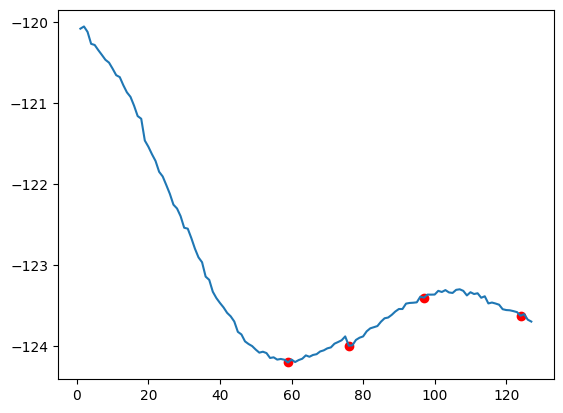

In [3]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

def mi_vectorized(data, delay, bins=32):
    # Compute 2D histogram and marginals
    p_xy, x_e, y_e = np.histogram2d(data[:-delay], data[delay:], bins=bins, density=True)
    p_x = p_xy.sum(axis=1, keepdims=True)
    p_y = p_xy.sum(axis=0, keepdims=True)
    
    # MI = sum( Pxy * log(Pxy / (Px*Py)) )
    idx = p_xy > 0  # Avoid log(0)
    return np.sum(p_xy[idx] * np.log(p_xy[idx] / (p_x @ p_y)[idx]))

data_to_test = train[:64]
# data_to_test = np.random.normal(0,1,data_to_test.shape)

# Process batch: [64, seq_length]
lags = np.arange(1, 128)
# Compute average MI across the first 64 series
MI = np.mean([[mi_vectorized(X, l) for l in lags] for X in data_to_test], axis=0)

# Find and plot peaks
peaks, _ = scipy.signal.find_peaks(-MI, distance=15)
plt.plot(lags, MI)
plt.scatter(lags[peaks], MI[peaks], color='red')
print(f"Optimal Lags: {lags[peaks]}")

Итого у нас выходит ~60 лагов внутри временного ряда

TS dim is [3]


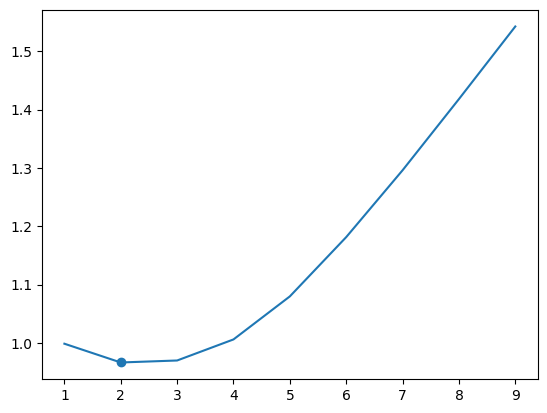

In [4]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors as NN
from joblib import Parallel,delayed

emb = lambda s, d: s[np.arange(len(s)-d+1)[:, None] + np.arange(d)]

def get_fnn(X, lags):
    X = (X-np.mean(X))/np.std(X)
    res = []
    for d in lags:
        e2 = emb(X, d+1)
        e1=e2[:,:-1]
        idx = NN(n_neighbors=2).fit(e1).kneighbors(e1,return_distance=False)[:,-1]
        new_dist = np.linalg.norm(e2-e2[idx],2,axis=-1)
        
        res.append(new_dist.mean())
    return res

lags = np.arange(1, 10)
data=train[:16]
# data = np.random.normal(0,1,data.shape)

FNN = np.mean(Parallel(n_jobs=-1)([delayed(get_fnn)(X, lags) for X in data]), axis=0)
peaks = scipy.signal.find_peaks(-FNN,distance=5)[0]
plt.plot(lags,FNN)
plt.scatter(peaks+1,FNN[peaks])
print("TS dim is",peaks+2)

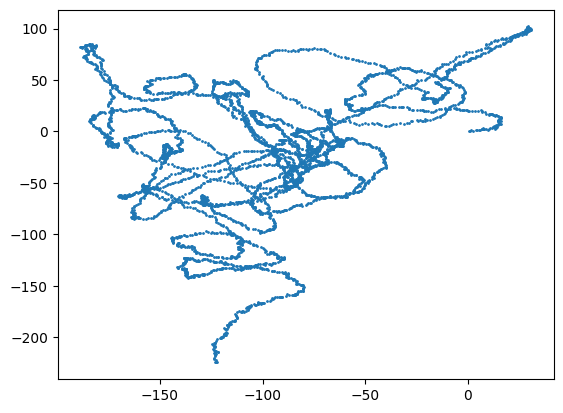

In [5]:
import random
# Любые пары из датасета выглядят как случайное блуждание

ind1 = random.randint(0,len(train)-1)
ind2 = random.randint(0,len(train)-1)
plt.scatter(train[ind1].cumsum(),train[ind2].cumsum(),s=1)

In [6]:
X_train = train[:,:-1]
y_train = train[:,1:]

X_test = test[:,:-1]
y_test = test[:,1:]

In [25]:
import numpy as np
from aeon.regression.convolution_based import RocketRegressor, HydraRegressor, MiniRocketRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Reshape X to (n_cases, n_channels, n_timepoints)
X_train_3d = X_train[:, np.newaxis, :]
X_test_3d = X_test[:, np.newaxis, :]

# 2. Prepare y as (n_cases,)
y_train_1d = y_train[:, -1] 
y_test_1d = y_test[:, -1]

# 3. Initialize and Fit
reg = MiniRocketRegressor(n_kernels=2000, n_jobs=-1, random_state=42)
reg.fit(X_train_3d, y_train_1d)

# 4. Predict
preds_train = reg.predict(X_train_3d)
preds_test = reg.predict(X_test_3d)

# 5. Calculate Metrics
mse_train = mean_squared_error(y_train_1d, preds_train)
r2_train = r2_score(y_train_1d, preds_train)

mse_test = mean_squared_error(y_test_1d, preds_test)
r2_test = r2_score(y_test_1d, preds_test)

# 6. Print Results
print("-" * 30)
print(f"{'Metric':<10} | {'Train':<10} | {'Test':<10}")
print("-" * 30)
print(f"{'MSE':<10} | {mse_train:.4f} | {mse_test:.4f}")
print(f"{'R2 Score':<10} | {r2_train:.4f} | {r2_test:.4f}")
print("-" * 30)

------------------------------
Metric     | Train      | Test      
------------------------------
MSE        | 0.1680 | 0.3883
R2 Score   | 0.7209 | 0.3143
------------------------------


Прогнозирование для 100 рядов...


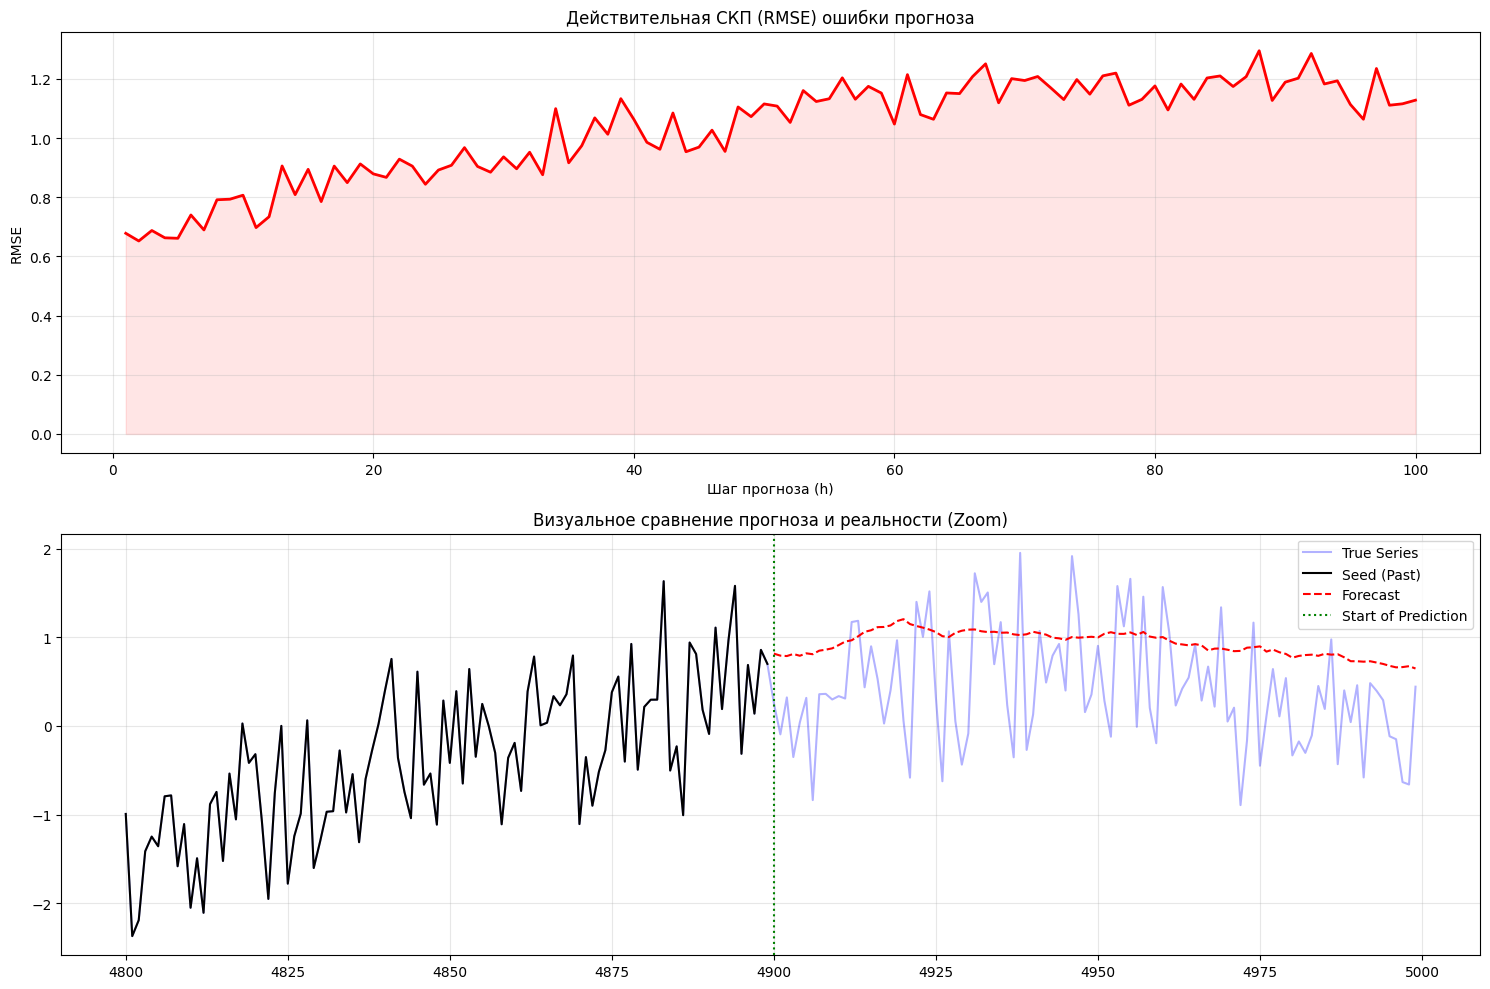

RMSE h=1: 0.6781
RMSE h=100: 1.1280


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ПАРАМЕТРЫ (Downscaled для скорости) ---
n_test_total = len(X_test_3d)
n_test_samples = 100        # Рассчитываем по 100 реализациям для скорости
steps_to_generate = 100      # Горизонт прогноза
seed_len = 4900             # Точка начала прогноза (из 5000)

# Выбираем случайные индексы для расчета
random_indices = np.random.choice(n_test_total, n_test_samples, replace=False)
subset_test = test[random_indices]

# --- 2. УСКОРЕННАЯ ГЕНЕРАЦИЯ ---
current_windows = np.zeros((n_test_samples, 1, 4999))
current_windows[:, 0, -seed_len:] = subset_test[:, :seed_len]
all_preds = np.zeros((n_test_samples, steps_to_generate))

print(f"Прогнозирование для {n_test_samples} рядов...")
for h in range(steps_to_generate):
    preds = reg.predict(current_windows) 
    all_preds[:, h] = preds
    current_windows = np.roll(current_windows, -1, axis=2)
    current_windows[:, 0, -1] = preds

# --- 3. РАСЧЕТ RMSE ---
y_true_future = subset_test[:, seed_len : seed_len + steps_to_generate]
rmse_per_step = np.sqrt(np.mean((all_preds - y_true_future)**2, axis=0))

# --- 4. ФИНАЛЬНЫЕ ГРАФИКИ ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# ГРАФИК 1: RMSE (СКП)
ax1.plot(range(1, steps_to_generate + 1), rmse_per_step, color='red', lw=2)
ax1.fill_between(range(1, steps_to_generate + 1), 0, rmse_per_step, color='red', alpha=0.1)
ax1.set_title("Действительная СКП (RMSE) ошибки прогноза")
ax1.set_xlabel("Шаг прогноза (h)")
ax1.set_ylabel("RMSE")
ax1.grid(True, alpha=0.3)

# ГРАФИК 2: ВИЗУАЛИЗАЦИЯ (Последний ряд из выборки)
view_count = 200 # Показываем последние 200 точек для наглядности
start_view = 5000 - view_count
indices = np.arange(start_view, 5000)

last_sample = subset_test[-1]
last_preds = all_preds[-1]

ax2.plot(indices, last_sample[start_view:], label="True Series", color='blue', alpha=0.3)
ax2.plot(np.arange(start_view, seed_len), last_sample[start_view:seed_len], label="Seed (Past)", color='black')
ax2.plot(np.arange(seed_len, 5000), last_preds, label="Forecast", color='red', linestyle='--')
ax2.axvline(x=seed_len, color='green', linestyle=':', label='Start of Prediction')
ax2.set_title("Визуальное сравнение прогноза и реальности (Zoom)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"RMSE h=1: {rmse_per_step[0]:.4f}")
print(f"RMSE h={steps_to_generate}: {rmse_per_step[-1]:.4f}")